In [25]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated, Literal

In [26]:
class Quadstate(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    d:float
    result:str

In [27]:
def show_equation(state:Quadstate):
    equation=f'{state['a']}x2{state['b']}x{state['c']}'
    return{'equation':equation}

In [28]:
def calc_d(state:Quadstate):
    d=state['b']**2-4*state['a']*state['c']
    return{'d':d}

In [29]:
def real_roots(state:Quadstate):
    root1=(-state['b']+state['d']**(0.5))/(2*state['a'])
    root2=(-state['b']-state['d']**(0.5))/(2*state['a'])
    result=f'the roots are {root1} and {root2}'
    return{'result':result}

In [30]:
def repeated_roots(state:Quadstate):
    root=(-state['b'])/(2*state['a'])
    result=f'the roots are {root} and {root}'
    return{'result':result}

In [31]:
def no_real_roots(state:Quadstate):
    result=f'no real roots '
    return{'result':result}

In [ ]:
# here u need to make a functipn that checks  acc to condition whether which fucntion to return 
def check_condition(state:Quadstate)->Literal['real_roots','no_real_roots','repeated_roots']:
    if state['d'] > 0:
        return "real_roots"
    elif state['d'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

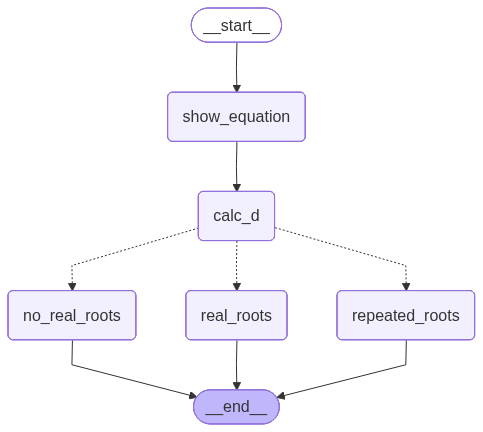

In [33]:
graph=StateGraph(Quadstate)
graph.add_node('show_equation',show_equation)
graph.add_node('calc_d',calc_d)
graph.add_node('no_real_roots',no_real_roots)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)

graph.add_edge(START,'show_equation')

graph.add_edge('show_equation','calc_d')
graph.add_conditional_edges('calc_d',check_condition)

graph.add_edge('real_roots',END)
graph.add_edge('no_real_roots',END)
graph.add_edge('repeated_roots',END)

workflow=graph.compile()
workflow


In [36]:
initial_state={
    'a':4,
    'b':4,
    "c":4
}
workflow.invoke(initial_state)

{'a': 4,
 'b': 4,
 'c': 4,
 'equation': '4x24x4',
 'd': -48,
 'result': 'no real roots '}